Importing libraries

In [1]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

Loading final model

In [2]:
final_model = joblib.load("../models/final_random_forest.pkl")

Loading test data

In [4]:
X_test = pd.read_csv("../data/processed/X_test_processed.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:,1]

Confusion Matrix

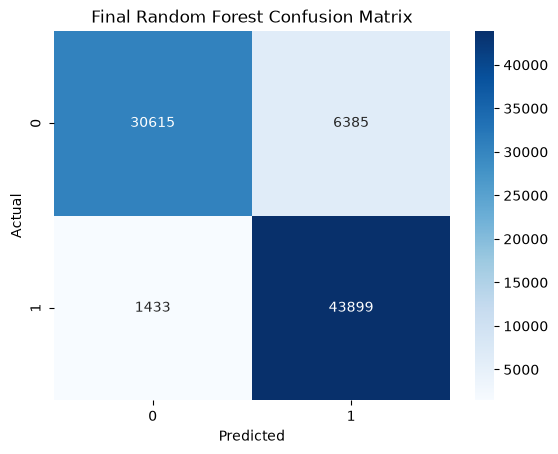

In [6]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt="d",cmap = 'Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Random Forest Confusion Matrix")

plt.show()

ROC Curve

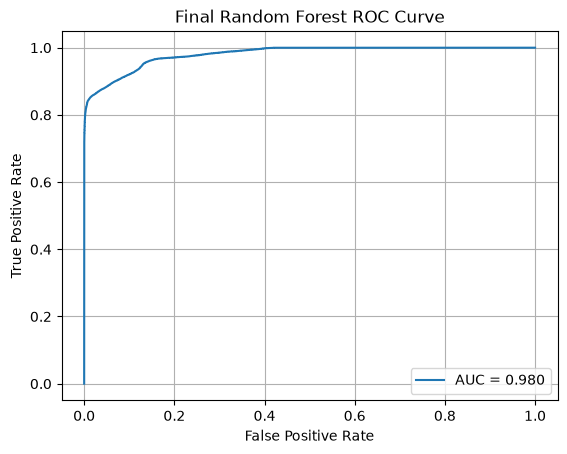

In [7]:
fpr, tpr, thresholds = roc_curve(y_test,y_prob)

auc = roc_auc_score(y_test,y_prob)

plt.plot(fpr,tpr,label=f"AUC = {auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Random Forest ROC Curve")
plt.legend()
plt.grid()

plt.show()

Feature Importance

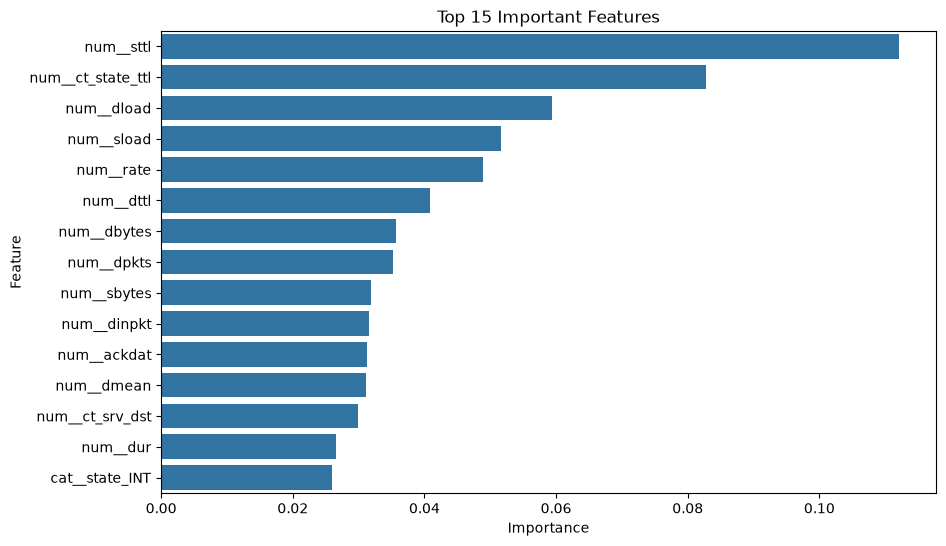

In [8]:
feature_names = np.load("../data/processed/feature_names.npy",allow_pickle=True)

importance = pd.DataFrame({"Feature": feature_names,"Importance": final_model.feature_importances_})
importance = importance.sort_values("Importance",ascending=False)

importance.head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(15),x="Importance",y="Feature")
plt.title("Top 15 Important Features")
plt.show()

## Final Model Evaluation Summary

The optimized Random Forest classifier was evaluated on the UNSW-NB15 test dataset.

### Final Model

Random Forest with optimized hyperparameters:

- Number of estimators: 300
- Maximum depth: 10
- Minimum samples split: 5
- Class weight: balanced

### Performance

- Accuracy: 90.5%
- Precision (Attack): 87%
- Recall (Attack): 97%
- F1-score (Attack): 92%
- ROC-AUC: 0.980

The model demonstrates strong capability in detecting malicious network traffic while maintaining a high recall rate, which is important for intrusion detection systems.